In [ ]:
# !pip install scikit-learn

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

### Loading the Dataset

In [2]:
df = pd.read_csv('House_Rent_Dataset (3).csv')

In [3]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


In [5]:
df.describe()

,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


### Handling Missing Value

In [6]:
df.isna().sum()

Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64

In [7]:
print('Total numbers of missing values:', df.isna().sum().sum())

Total numbers of missing values: 0


### Exploratory Data Analysis

<Axes: xlabel='Tenant Preferred', ylabel='count'>

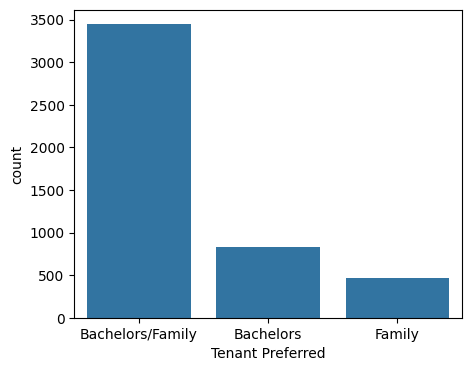

In [9]:
# Univariate EDA
plt.figure(figsize = (5, 4))
sns.countplot(data = df, x = 'Tenant Preferred')

In [27]:
df_house = df.drop(columns = 'Posted On')

In [28]:
df_house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   BHK                4746 non-null   int64 
 1   Rent               4746 non-null   int64 
 2   Size               4746 non-null   int64 
 3   Floor              4746 non-null   object
 4   Area Type          4746 non-null   object
 5   Area Locality      4746 non-null   object
 6   City               4746 non-null   object
 7   Furnishing Status  4746 non-null   object
 8   Tenant Preferred   4746 non-null   object
 9   Bathroom           4746 non-null   int64 
 10  Point of Contact   4746 non-null   object
dtypes: int64(4), object(7)
memory usage: 408.0+ KB


### Data Encoding

In [43]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [44]:
df_house.columns

Index(['BHK', 'Rent', 'Size', 'Floor', 'Area Type', 'Area Locality', 'City',
       'Furnishing Status', 'Tenant Preferred', 'Bathroom',
       'Point of Contact'],
      dtype='object')

In [34]:
names = list(df_house.select_dtypes(include = 'object').columns)

In [35]:
names

['Floor',
 'Area Type',
 'Area Locality',
 'City',
 'Furnishing Status',
 'Tenant Preferred',
 'Point of Contact']

In [36]:
df_strings = df_house[names]

In [37]:
df_strings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Floor              4746 non-null   object
 1   Area Type          4746 non-null   object
 2   Area Locality      4746 non-null   object
 3   City               4746 non-null   object
 4   Furnishing Status  4746 non-null   object
 5   Tenant Preferred   4746 non-null   object
 6   Point of Contact   4746 non-null   object
dtypes: object(7)
memory usage: 259.7+ KB


In [51]:
def encoder(col):
    df_house[col] = le.fit_transform(df_strings[col])

In [52]:
for i in names:
    encoder(i)

In [54]:
df_house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   BHK                4746 non-null   int64
 1   Rent               4746 non-null   int64
 2   Size               4746 non-null   int64
 3   Floor              4746 non-null   int64
 4   Area Type          4746 non-null   int64
 5   Area Locality      4746 non-null   int64
 6   City               4746 non-null   int64
 7   Furnishing Status  4746 non-null   int64
 8   Tenant Preferred   4746 non-null   int64
 9   Bathroom           4746 non-null   int64
 10  Point of Contact   4746 non-null   int64
dtypes: int64(11)
memory usage: 408.0 KB


### Feature Selection

<Axes: >

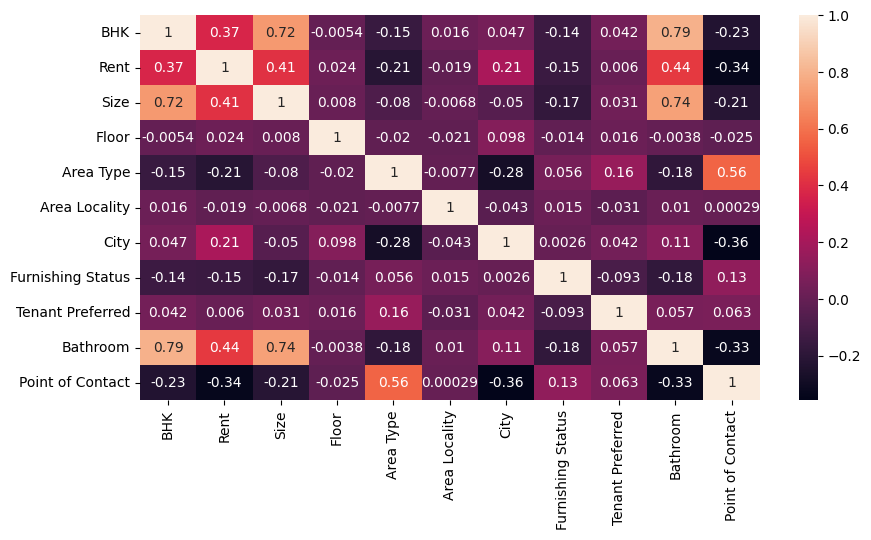

In [56]:
plt.figure(figsize = (10, 5))
sns.heatmap(df_house.corr(), annot = True)

In [63]:
x = df_house[['BHK', 'Size', 'Floor', 'Area Type', 
               'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred', 'Bathroom', 'Point of Contact']]

In [64]:
y = df_house['Rent']

### Data Splitting

In [65]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)

In [66]:
print('Total training rows:', x_train.shape[0])
print('Total training columns:', x_train.shape[1])
print('Total training:', y_train.shape[0])
print(x_test.shape)
print(y_test.shape)

Total training rows: 3796
Total training columns: 10
Total training: 3796
(950, 10)
(950,)


### Building a Machine Learning Model

In [67]:
model = LinearRegression()

In [68]:
import warnings
warnings.filterwarnings('ignore')
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Model Testing

In [70]:
pred = model.predict(x_test)

In [71]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, pred)
print('MAE: ', round(mae , 2))

MAE:  22839.86


In [72]:
print('Maximum Rent:', max(df_house['Rent']))
print('Minimum Rent:', min(df_house['Rent']))
print('Average Rent:', np.mean(df_house['Rent']))

Maximum Rent: 3500000
Minimum Rent: 1200
Average Rent: 34993.45132743363
